In [105]:
import pandas as pd

# Load the dataset
data = pd.read_csv('Food_Delivery_Time_Prediction.csv')

# Display dataset information
print(data.info())
print(data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [106]:
# For categorical variables, fill with the mode
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    mode_value = data[col].mode()[0]
    data[col] = data[col].fillna(mode_value)


In [107]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
categorical_columns = ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Vehicle_Type']
for col in categorical_columns:
    data[col] = encoder.fit_transform(data[col])


In [108]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
continuous_columns = ['Distance', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']
data[continuous_columns] = scaler.fit_transform(data[continuous_columns])


In [109]:
import numpy as np

def haversine(coord1, coord2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1 = map(np.radians, map(float, coord1.strip('()').split(',')))
    lat2, lon2 = map(np.radians, map(float, coord2.strip('()').split(',')))
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    r = 6371  # Radius of Earth in kilometers
    return r * c

data['Haversine_Distance'] = data.apply(lambda x: haversine(x['Customer_Location'], x['Restaurant_Location']), axis=1)
data.drop(['Customer_Location', 'Restaurant_Location'], axis=1, inplace=True)


In [110]:
# Create a binary target variable
threshold = 0.5  # Define a threshold for fast vs. delayed
data['Delivery_Status'] = (data['Delivery_Time'] > threshold).astype(int)
data.drop(['Delivery_Time'], axis=1, inplace=True)


In [111]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = data.drop(['Delivery_Status'], axis=1)
y = data['Delivery_Status']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [112]:
# Drop non-numeric columns (e.g., 'Order_ID' and any other non-numeric columns)
X_train = X_train.select_dtypes(include=['float64', 'int64'])
X_test = X_test.select_dtypes(include=['float64', 'int64'])

# Ensure that the target variable (y_train, y_test) is still correct (binary classification)
print(X_train.head())  # Check the feature data
print(y_train.head())  # Check the target data


     Distance  Delivery_Person_Experience  Restaurant_Rating  Customer_Rating  \
169  0.156276                           3                3.5              4.5   
97   0.809270                           1                4.7              5.0   
31   0.495078                           9                4.0              3.9   
12   0.033634                           7                4.0              4.7   
35   0.931501                           3                3.2              3.8   

     Order_Cost  Tip_Amount  Haversine_Distance  
169    0.615043    0.117360          341.255209  
97     0.487025    0.479797          419.709630  
31     0.637949    0.629746          207.615400  
12     0.919738    0.107716          444.731703  
35     0.365198    0.002030          607.738352  
169    1
97     1
31     0
12     0
35     0
Name: Delivery_Status, dtype: int32


In [113]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train the model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluation
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))


Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.44      0.46        25
           1       0.62      0.66      0.64        35

    accuracy                           0.57        60
   macro avg       0.55      0.55      0.55        60
weighted avg       0.56      0.57      0.56        60

Accuracy: 0.5666666666666667


In [114]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning
param_grid = {'n_neighbors': range(1, 20)}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Optimal K
best_k = grid_search.best_params_['n_neighbors']
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluation
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.40      0.43        25
           1       0.62      0.69      0.65        35

    accuracy                           0.57        60
   macro avg       0.55      0.54      0.54        60
weighted avg       0.56      0.57      0.56        60

Accuracy: 0.5666666666666667


In [115]:
from sklearn.tree import DecisionTreeClassifier

# Train the model
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.32      0.37        25
           1       0.60      0.71      0.65        35

    accuracy                           0.55        60
   macro avg       0.52      0.52      0.51        60
weighted avg       0.53      0.55      0.53        60

Accuracy: 0.55


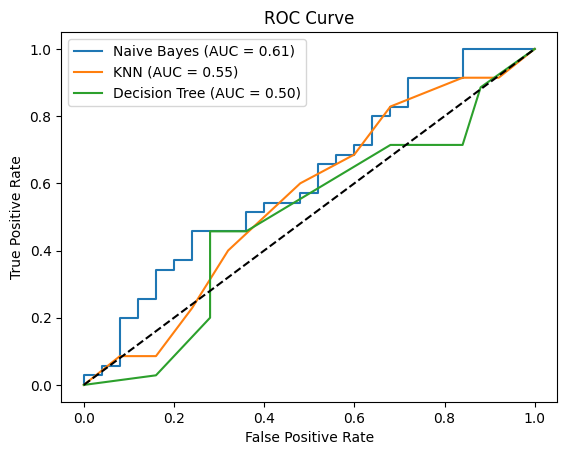

In [116]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot ROC Curves
models = {'Naive Bayes': nb_model, 'KNN': knn_model, 'Decision Tree': dt_model}
for name, model in models.items():
    y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.44      0.46        25
           1       0.62      0.66      0.64        35

    accuracy                           0.57        60
   macro avg       0.55      0.55      0.55        60
weighted avg       0.56      0.57      0.56        60

Naive Bayes Accuracy: 0.5666666666666667
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.48      0.47        25
           1       0.62      0.60      0.61        35

    accuracy                           0.55        60
   macro avg       0.54      0.54      0.54        60
weighted avg       0.55      0.55      0.55        60

KNN Accuracy: 0.55
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.56      0.46        25
           1       0.54      0.37      0.44        35

    accuracy        

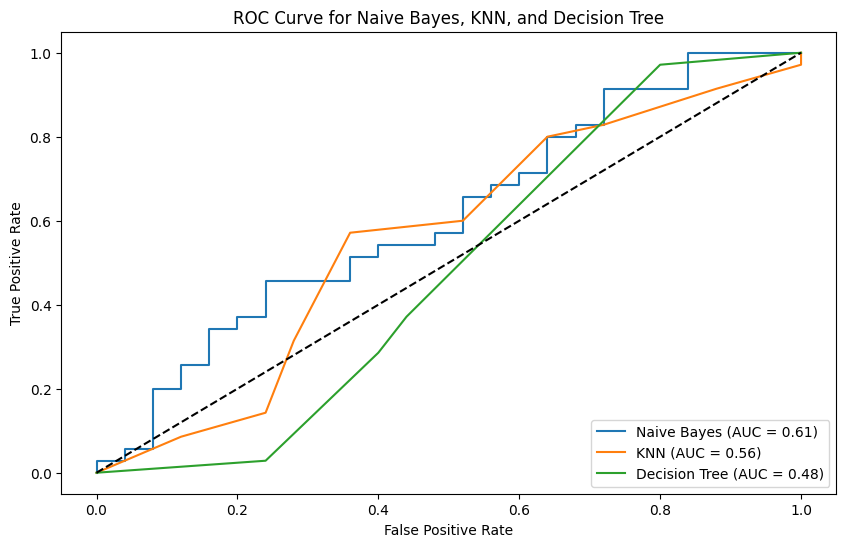

Confusion Matrix for Naive Bayes:
 [[11 14]
 [12 23]]
Accuracy for Naive Bayes: 0.5666666666666667

Confusion Matrix for KNN:
 [[12 13]
 [14 21]]
Accuracy for KNN: 0.55

Confusion Matrix for Decision Tree:
 [[14 11]
 [22 13]]
Accuracy for Decision Tree: 0.45



In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

# Load the dataset
data = pd.read_csv('Food_Delivery_Time_Prediction.csv')

# Fill missing values
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    mode_value = data[col].mode()[0]
    data[col] = data[col].fillna(mode_value)

# Encode categorical variables
encoder = LabelEncoder()
categorical_columns = ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Vehicle_Type']
for col in categorical_columns:
    data[col] = encoder.fit_transform(data[col])

# Normalize continuous features
scaler = MinMaxScaler()
continuous_columns = ['Distance', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']
data[continuous_columns] = scaler.fit_transform(data[continuous_columns])

# Haversine distance calculation
def haversine(coord1, coord2):
    lat1, lon1 = map(np.radians, map(float, coord1.strip('()').split(',')))
    lat2, lon2 = map(np.radians, map(float, coord2.strip('()').split(',')))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    r = 6371  # Radius of Earth in kilometers
    return r * c

# Compute Haversine distance
data['Haversine_Distance'] = data.apply(lambda x: haversine(x['Customer_Location'], x['Restaurant_Location']), axis=1)
data.drop(['Customer_Location', 'Restaurant_Location'], axis=1, inplace=True)

# Create binary target variable for Delivery Status (Fast or Delayed)
threshold = 0.5
data['Delivery_Status'] = (data['Delivery_Time'] > threshold).astype(int)
data.drop(['Delivery_Time'], axis=1, inplace=True)

# Split data into features and target
X = data.drop(['Delivery_Status'], axis=1)
y = data['Delivery_Status']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Ensure that the target variable is still correct (binary classification)
X_train = X_train.select_dtypes(include=['float64', 'int64'])
X_test = X_test.select_dtypes(include=['float64', 'int64'])

# Naive Bayes Model
nb_model = GaussianNB()

# Hyperparameter tuning: Although GaussianNB has few hyperparameters, you can try adjusting priors.
# In practice, Gaussian Naive Bayes doesn't usually need heavy tuning, but let's demonstrate.
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Naive Bayes Evaluation
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

# KNN Model with Hyperparameter Tuning
knn_param_grid = {'n_neighbors': range(1, 21), 'weights': ['uniform', 'distance']}
grid_search_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

# KNN Evaluation
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

# Decision Tree with Hyperparameter Tuning
dt_param_grid = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10], 'class_weight': ['balanced', None]}
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

# Decision Tree Evaluation
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Plot ROC Curves for all models
models = {'Naive Bayes': nb_model, 'KNN': best_knn, 'Decision Tree': best_dt}
plt.figure(figsize=(10, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_prob = model.predict(X_test)  # Use predict for binary labels
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Naive Bayes, KNN, and Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Confusion Matrices
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {name}:\n", cm)
    print(f"Accuracy for {name}: {accuracy_score(y_test, y_pred)}\n")
